In [421]:
#%%
import math
import numpy as np

import inspect
import importlib

import scipy.interpolate
from scipy import stats
from scipy.stats import norm

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
from matplotlib import patches as mpatches
from matplotlib.collections import LineCollection
import matplotlib.lines as mlines
from matplotlib import colormaps

import seaborn as sns


plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Analysis                            import *

from fft_architecture_exploration                        import *

path_to_save_svg = "Saved_Data"


rng = np.random.default_rng(42)

In [422]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [423]:
def F_p_kWh_to_p_J (F_p_kWh):

    return F_p_kWh / 3600000 

def F_p_mAh_to_p_kWh (F_p_mAh, V):

    return F_p_mAh * 1e6 / (V)

def F_p_mAh_to_p_J (F_p_mAh, V):

    return F_p_mAh / (3600/1000 * V)

In [424]:
grid_data = {
"World"                         : 0.458,  
"China"                         : 0.525, 
"US"                            : 0.384, 
"France"                        : 0.041, 
"Taiwan"                        : 0.633, 
"ASEAN"                         : 0.56501,  
"Africa"                        : 0.52988,  
"Asia"                          : 0.5444,   
"EU"                            : 0.2099,   
"Europe"                        : 0.28268,  
"G20"                           : 0.45329,  
"G7"                            : 0.34242,  
"Latin America and Caribbean"   : 0.24697,  
"Middle East"                   : 0.63461,  
"North America"                 : 0.35995,  
"OECD"                          : 0.33593,   
"Oceania"                       : 0.46987
}


In [ ]:
#-------------- GRID ----------------------
F_p_kWh_grid = grid_data["World"]
#-------------- Non-Rechargeable Batt. ----------------------
V_alkaline_AA = 1.5
F_p_mAh_nrBatt           = (3.65*0.136/3)/3300
F_p_mAh_nrBatt_Hamade    = (0.0724)/3300
F_p_mAh_nrBatt_hhc       = 10.40 / (50*3) / 3300 
F_p_mAh_nrBatt_Olivetti  = (4.3/30) / 3300 
F_p_kWh_nrBatt_Mulders   = 0.940 *(3600*1000)/ (20*365*10) 
#-------------- Rechargeable Batt. ----------------------
F_p_Wh_rBatt_LP        = 0.03/0.144 # Van Mulders LP
F_p_Wh_rBatt_MP        = 0.78/3.12 # Van Mulders MP
F_p_Wh_rBatt_Mulders   = np.mean([F_p_Wh_rBatt_LP,F_p_Wh_rBatt_MP])
F_p_Wh_rBatt_NMC811    = 75    /1000 # Peiseler 2024
F_p_Wh_rBatt_LFP       = 61.5  /1000 # Peiseler 2024
F_p_Wh_rBatt_NCM111    = 73    /1000 # Melin, H.E. Analysis of the Climate Impact of Lithium-Ion Batteries and How to Measure It;  mod. from Dai et al 2019)
F_p_Wh_rBatt_All       = 31    /1000 # Allocation at substitution : An In-Depth Life Cycle Assessment (LCA) of Lithium-Ion Battery for Climate Impact Mitigation Strategies
F_p_Wh_rBatt_Cut       = 25.38 /1000 # Cut-off                    : An In-Depth Life Cycle Assessment (LCA) of Lithium-Ion Battery for Climate Impact Mitigation Strategies
F_p_Wh_rBatt_Con       = 6.5   /1000 # Consequential              : An In-Depth Life Cycle Assessment (LCA) of Lithium-Ion Battery for Climate Impact Mitigation Strategies

F_p_Wh_rBatt_Fairphone = F_p_mAh_to_p_kWh(1.6 /3900, V=1.5)/1000 # Fairphone

#-------------- Rechargeable Batt. ----------------------
F_EH    = np.array([0.125,0.235,0.35,0.47])
P_mw_EH = np.array([0.27 ,0.54 ,0.82,1.09])
F_p_W_EH = np.mean(F_EH/P_mw_EH) *1000



#-------------- UAV Based ----------------------
E_charge_p_flight = 2000
F_UAV_Mulders     = 0.555
F_p_flight_Mulders = (F_UAV_Mulders-0.055)/36.5
F_p_J_UAV_Mulders  = F_p_flight_Mulders/E_charge_p_flight



In [426]:
print("F_p_flight = %.2e kgCO2/flight" % (F_p_flight_Mulders))
print("F_p_kWh    = %.2e kgCO2/kWh"    % (3600*1000*F_p_J_UAV_Mulders))

F_p_flight = 1.37e-02 kgCO2/flight
F_p_kWh    = 2.47e+01 kgCO2/kWh


In [ ]:
print("F_p_W_EH = %.2e kgCO2/W" % F_p_W_EH)

F_p_W_EH = 4.39e+02 kgCO2/W
1170.1030927835052


In [428]:
print("F_p_kWh_grid             = %.2e kgCO2/kWh" % F_p_kWh_grid        )
print("F_p_kWh_nr_batt_Pirson   = %.2e kgCO2/kWh" % F_p_mAh_to_p_kWh(F_p_mAh_nrBatt, V_alkaline_AA))
print("F_p_kWh_nr_batt_Hamade   = %.2e kgCO2/kWh" % F_p_mAh_to_p_kWh(F_p_mAh_nrBatt_Hamade, V_alkaline_AA))
print("F_p_kWh_nr_batt_hhc      = %.2e kgCO2/kWh" % F_p_mAh_to_p_kWh(F_p_mAh_nrBatt_hhc, V_alkaline_AA))
print("F_p_kWh_nr_batt_Olivetti = %.2e kgCO2/kWh" % F_p_mAh_to_p_kWh(F_p_mAh_nrBatt_Olivetti, V_alkaline_AA))
print("F_p_kWh_nr_batt_Mulders  = %.2e kgCO2/kWh" % F_p_kWh_nrBatt_Mulders)

F_p_kWh_grid             = 4.58e-01 kgCO2/kWh
F_p_kWh_nr_batt_Pirson   = 3.34e+01 kgCO2/kWh
F_p_kWh_nr_batt_Hamade   = 1.46e+01 kgCO2/kWh
F_p_kWh_nr_batt_hhc      = 1.40e+01 kgCO2/kWh
F_p_kWh_nr_batt_Olivetti = 2.90e+01 kgCO2/kWh
F_p_kWh_nr_batt_Mulders  = 4.64e+01 kgCO2/kWh


In [456]:

print("F_p_kWh_rBatt_Mulders        = %.2e kgCO2/kWh" % (1000*F_p_Wh_rBatt_Mulders)    )
print("F_p_kWh_rBatt_NMC811         = %.2e kgCO2/kWh" % (1000*F_p_Wh_rBatt_NMC811)     )
print("F_p_kWh_rBatt_LFP            = %.2e kgCO2/kWh" % (1000*F_p_Wh_rBatt_LFP)        )
print("F_p_Wh_rBatt_Fairphone       = %.2e kgCO2/kWh" % (1000*F_p_Wh_rBatt_Fairphone)  )
print("F_p_Wh_rBatt_All             = %.2e kgCO2/kWh" % (1000*F_p_Wh_rBatt_All)  )
print("F_p_Wh_rBatt_Cut             = %.2e kgCO2/kWh" % (1000*F_p_Wh_rBatt_Cut)  )
print("F_p_Wh_rBatt_Con             = %.2e kgCO2/kWh" % (1000*F_p_Wh_rBatt_Con)  )

print(np.mean([F_p_Wh_rBatt_Mulders,F_p_Wh_rBatt_NMC811,F_p_Wh_rBatt_LFP,F_p_Wh_rBatt_Fairphone,F_p_Wh_rBatt_All,F_p_Wh_rBatt_Cut,F_p_Wh_rBatt_Con])*1000)

F_p_kWh_rBatt_Mulders        = 2.29e+02 kgCO2/kWh
F_p_kWh_rBatt_NMC811         = 7.50e+01 kgCO2/kWh
F_p_kWh_rBatt_LFP            = 6.15e+01 kgCO2/kWh
F_p_Wh_rBatt_Fairphone       = 2.74e+02 kgCO2/kWh
F_p_Wh_rBatt_All             = 3.10e+01 kgCO2/kWh
F_p_Wh_rBatt_Cut             = 2.54e+01 kgCO2/kWh
F_p_Wh_rBatt_Con             = 6.50e+00 kgCO2/kWh
100.29299145299144


In [452]:
F_p_mm2 = 0.026
F_p_mm2 = 0.97/100

A_chip = 10/((90/65)**2) # 0.6

F_p_chip = F_p_mm2 * A_chip
print("F_p_mm2  = %.2e  gCO2/mm2"  % (F_p_mm2*1000))
print("F_p_chip = %.2e kgCO2/chip" % F_p_chip)

F_p_mm2  = 9.70e+00  gCO2/mm2
F_p_chip = 5.06e-02 kgCO2/chip


In [ ]:
F_p_mm2 = 0.026
F_p_mm2 = 0.97/100

A_chip = 10/((90/65)**2) # 0.6

F_p_chip = F_p_mm2 * A_chip
print("F_p_chip = %.2e kgCO2/chip" % F_p_chip)

In [438]:
E_p_pt = 6e-9

F_p_pt_grid = E_p_pt * F_p_kWh_to_p_J(F_p_kWh_grid)        
F_p_pt_batt = E_p_pt * F_p_mAh_to_p_J(F_p_mAh_nrBatt, 1.2)
print("F_p_J_grid = %.2e kgCO2/J" % F_p_kWh_to_p_J(F_p_kWh_grid) )
print("F_p_J_batt = %.2e kgCO2/J" % F_p_mAh_to_p_J(F_p_mAh_nrBatt, 1.2))
print()
print("F_p_pt_grid = %.2e kgCO2/pt" % F_p_pt_grid)
print("F_p_pt_batt = %.2e kgCO2/pt" % F_p_pt_batt)

F_p_J_grid = 1.27e-07 kgCO2/J
F_p_J_batt = 1.16e-05 kgCO2/J

F_p_pt_grid = 7.63e-16 kgCO2/pt
F_p_pt_batt = 6.96e-14 kgCO2/pt


In [439]:
LT_years = 10
LT_s     = LT_years * 365 * 24 * 3600

fs = 10e3

In [440]:
time_between_recharge_s = 60*60*24 * (6*30) # 6 months
F_rBatt_Mulders = (E_p_pt*fs* time_between_recharge_s) * F_p_kWh_to_p_J(F_p_Wh_rBatt_Mulders*1000)
F_rBatt_LPF     = (E_p_pt*fs* time_between_recharge_s) * F_p_kWh_to_p_J(F_p_Wh_rBatt_LFP*1000)
F_rBatt_NMC811  = (E_p_pt*fs* time_between_recharge_s) * F_p_kWh_to_p_J(F_p_Wh_rBatt_NMC811*1000)
F_rBatt_FairP   = (E_p_pt*fs* time_between_recharge_s) * F_p_kWh_to_p_J(F_p_Wh_rBatt_Fairphone*1000)
F_rBatt_All     = (E_p_pt*fs* time_between_recharge_s) * F_p_kWh_to_p_J(F_p_Wh_rBatt_All*1000)
F_rBatt_Cut     = (E_p_pt*fs* time_between_recharge_s) * F_p_kWh_to_p_J(F_p_Wh_rBatt_Cut*1000)
F_rBatt_Con     = (E_p_pt*fs* time_between_recharge_s) * F_p_kWh_to_p_J(F_p_Wh_rBatt_Con*1000)
print("F_r_batt_Mulders  = %.2e kgCO2" % F_rBatt_Mulders )
print("F_r_batt_LPF      = %.2e kgCO2" % F_rBatt_LPF     )
print("F_r_batt_NMC811   = %.2e kgCO2" % F_rBatt_NMC811  )
print("F_r_batt_FairP    = %.2e kgCO2" % F_rBatt_FairP  )
print("F_rBatt_All       = %.2e kgCO2" % F_rBatt_All  )
print("F_rBatt_Cut       = %.2e kgCO2" % F_rBatt_Cut  )
print("F_rBatt_Con       = %.2e kgCO2" % F_rBatt_Con  )

F_r_batt_Mulders  = 5.94e-02 kgCO2
F_r_batt_LPF      = 1.59e-02 kgCO2
F_r_batt_NMC811   = 1.94e-02 kgCO2
F_r_batt_FairP    = 7.09e-02 kgCO2
F_rBatt_All       = 8.04e-03 kgCO2
F_rBatt_Cut       = 6.58e-03 kgCO2
F_rBatt_Con       = 1.68e-03 kgCO2


In [441]:
F_op_grid       = F_p_pt_grid * fs * LT_s
F_op_nr_batt    = F_p_pt_batt * fs * LT_s
F_op_EH         = (F_p_W_EH)  * fs * E_p_pt 

F_op_r_batt_Mulders      = F_rBatt_Mulders   + F_p_pt_grid * fs * LT_s
F_op_r_batt_LPF          = F_rBatt_LPF       + F_p_pt_grid * fs * LT_s
F_op_r_batt_NMC811       = F_rBatt_NMC811    + F_p_pt_grid * fs * LT_s


F_op_UAV       = F_p_J_UAV_Mulders * fs * LT_s *E_p_pt

F_p_J_UAV_Mulders
print("F_p_chip = %.2e kgCO2" % F_p_chip)
print("----------------------------")
print("F_op_grid            = %.2e kgCO2" % F_op_grid)
print("F_op_nr_batt         = %.2e kgCO2" % F_op_nr_batt)
print("F_op_EH              = %.2e kgCO2" % F_op_EH)
print("F_op_r_batt_Mulders  = %.2e kgCO2" % F_op_r_batt_Mulders      )
print("F_op_r_batt_LPF      = %.2e kgCO2" % F_op_r_batt_LPF          )
print("F_op_r_batt_NMC811   = %.2e kgCO2" % F_op_r_batt_NMC811       )
print("F_op_UAV             = %.2e kgCO2" % F_op_UAV                 )
print("----------------------------")
print("alpha_grid              = %.2e" % (F_p_chip/(F_op_grid        +F_p_chip)))
print("alpha_nr_batt           = %.2e" % (F_p_chip/(F_op_nr_batt     +F_p_chip)))
print("alpha_EH                = %.2e" % (F_p_chip/(F_op_EH          +F_p_chip)))
print("alpha_r_battF_Mulders   = %.2e" % (F_p_chip/(F_op_r_batt_Mulders +F_p_chip)))
print("alpha_r_battF_LPF       = %.2e" % (F_p_chip/(F_op_r_batt_LPF     +F_p_chip)))
print("alpha_r_battF_NMC811    = %.2e" % (F_p_chip/(F_op_r_batt_NMC811  +F_p_chip)))
print("alpha_UAV               = %.2e" % (F_p_chip/(F_op_UAV  +F_p_chip)))

F_p_chip = 5.06e-02 kgCO2
----------------------------
F_op_grid            = 2.41e-03 kgCO2
F_op_nr_batt         = 2.20e-01 kgCO2
F_op_EH              = 2.63e-02 kgCO2
F_op_r_batt_Mulders  = 6.18e-02 kgCO2
F_op_r_batt_LPF      = 1.83e-02 kgCO2
F_op_r_batt_NMC811   = 2.18e-02 kgCO2
F_op_UAV             = 1.30e-01 kgCO2
----------------------------
alpha_grid              = 9.55e-01
alpha_nr_batt           = 1.87e-01
alpha_EH                = 6.58e-01
alpha_r_battF_Mulders   = 4.50e-01
alpha_r_battF_LPF       = 7.34e-01
alpha_r_battF_NMC811    = 6.98e-01
alpha_UAV               = 2.81e-01


# Alpha sensitivity: power-supply scheme x sampling frequency

Generalizes the single-point $\alpha$ computation above to arrays of parameter values per power-supply scheme (grid regions, battery types, energy-harvesting sources) and an array of sampling frequencies $f_s$.

In [480]:

E_p_pt = 6e-9

LT_years = 10
LT_s     = LT_years * 365 * 24 * 3600

fs = 10e3

time_between_recharge_s = 60*60*24 * (3*30) # 6 months
charge_batt_uav = 2000

In [481]:
def alpha_metered(F_p_J, fs, E_p_pt=E_p_pt, F_p_chip=F_p_chip, LT_s=LT_s):
    """Alpha for schemes whose footprint accrues with energy drawn over the node lifetime (grid, battery)."""
    F_op = E_p_pt * F_p_J * fs * LT_s
    return F_p_chip / (F_op + F_p_chip)


def alpha_uav_recharge(F_p_flight, fs,E_batt=charge_batt_uav, E_p_pt=E_p_pt, F_p_chip=F_p_chip, LT_s=LT_s):
    """Alpha for schemes whose footprint accrues with energy drawn over the node lifetime (grid, battery)."""
    F_op = (F_p_flight/ E_batt)  * fs * LT_s *E_p_pt
    return F_p_chip / (F_op + F_p_chip)

def alpha_recharge(F_p_Wh,F_p_J, fs,t_rech=time_between_recharge_s, E_p_pt=E_p_pt, F_p_chip=F_p_chip, LT_s=LT_s):
    """Alpha for schemes whose footprint accrues with energy drawn over the node lifetime (grid, battery)."""
    F_op = (E_p_pt*fs* time_between_recharge_s) * F_p_kWh_to_p_J(F_p_Wh*1000) + E_p_pt * F_p_J * fs * LT_s
    return F_p_chip / (F_op + F_p_chip)

def alpha_harvested(F_p_W, fs, E_p_pt=E_p_pt, F_p_chip=F_p_chip):
    """Alpha for energy harvesting, whose footprint scales with the harvester sized for the average power draw."""
    F_op = F_p_W * fs * E_p_pt
    return F_p_chip / (F_op + F_p_chip)

In [482]:
# ---- Power-supply scheme variants -----------------------------------------

# ---- GRID-------------------
grid_labels = ["World",'Taiwan','France']
grid_F_p_J  = F_p_kWh_to_p_J(np.array([grid_data[k] for k in grid_labels]) )

# ---- NR Batt --------------
nr_batt_labels = np.array(["AA battery\nPirson", "AA battery\nOlivetti"])
nr_batt_F_p_J  = np.array([
    F_p_mAh_to_p_J(F_p_mAh_nrBatt, V_alkaline_AA),
    F_p_mAh_to_p_J(F_p_mAh_nrBatt_Olivetti, V_alkaline_AA),
])
# ---- EH --------------
eh_labels = np.array(["Solar EH"])
eh_F_p_W  = np.array([F_p_W_EH])

# ---- EH --------------
uav_labels = np.array(["UAV Recharge"])
uav_F_p_W  = np.array([F_p_flight_Mulders])

# ---- R Batt  --------------
r_batt_labels = np.array(["Cut-off","LFP","NMC811"])
r_batt_F_p_Wh  = np.array([
    F_p_Wh_rBatt_Cut,
    F_p_Wh_rBatt_LFP,
    F_p_Wh_rBatt_NMC811,
])

# --------------
N_fs     = 1000
fs_log_min = 1
fs_log_max = 5
fs_array = np.logspace(start=fs_log_min,stop=fs_log_max,base=10,num=N_fs+1,endpoint=True) #np.array([1e2, 1e3, 1e4, 1e5, 1e6])


# ---- Alpha for every (scheme variant, fs) pair -----------------------------

alpha_grid_res     = alpha_metered     (fs = fs_array[None, :], F_p_J =  grid_F_p_J[:, None]    ,    )
alpha_nr_batt_res  = alpha_metered     (fs = fs_array[None, :], F_p_J  = nr_batt_F_p_J[:, None] ,    )
alpha_r_batt_res   = alpha_recharge    (fs = fs_array[None, :], F_p_Wh = r_batt_F_p_Wh[:, None] , F_p_J =F_p_kWh_to_p_J(grid_data["World"])   )
alpha_eh_res       = alpha_harvested   (fs = fs_array[None, :], F_p_W  = eh_F_p_W [:, None]     ,    )
alpha_uav_res      = alpha_uav_recharge(fs = fs_array[None, :], F_p_flight = uav_F_p_W[:, None])

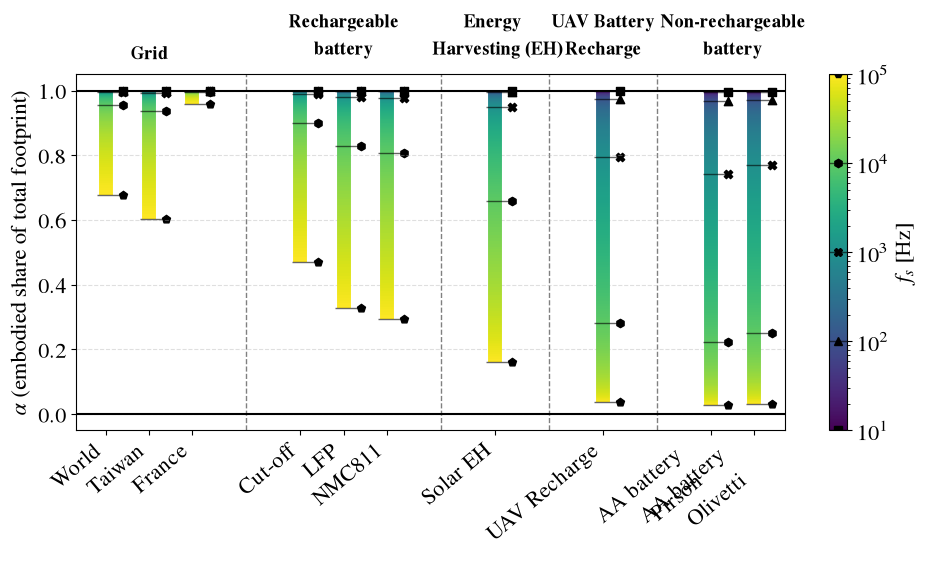

In [483]:
scheme_names  = ['Grid'          ,  'Rechargeable\nbattery'       , 'Energy \n Harvesting (EH)'  ,  'UAV Battery\nRecharge'          ,   'Non-rechargeable\nbattery'             ]
scheme_labels = [grid_labels     ,  r_batt_labels                 , eh_labels                    ,  uav_labels                       ,    nr_batt_labels          ]
scheme_alphas = [alpha_grid_res  ,  alpha_r_batt_res              , alpha_eh_res                 ,  alpha_uav_res                    ,    alpha_nr_batt_res       ]

#scheme_names  = ['Grid'          , 'Energy \n Harvesting (EH)'  ,  'UAV Battery\nRecharge'        ,   'Non-rechargeable\nbattery'             ]
#scheme_labels = [grid_labels     , eh_labels                    ,  uav_labels                     ,    nr_batt_labels          ]
#scheme_alphas = [alpha_grid_res  , alpha_eh_res                 ,  alpha_uav_res                  ,    alpha_nr_batt_res       ]

gap = 1.5  # extra x-spacing left between scheme groups, for the group header

x_labels, x_ticks, group_ranges = [], [], []
offset = 0.0
for labels in scheme_labels:
    positions = offset + np.arange(len(labels))
    x_ticks.extend(positions)
    x_labels.extend(labels)
    group_ranges.append((positions[0], positions[-1]))
    offset = positions[-1] + 1 + gap

fig, ax = plt.subplots(figsize=(max(10, 0.7 * len(x_labels)), 6))

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=40, ha='right')
ax.set_xlim(-0.7, offset - gap - 0.3)

cmap = colormaps['viridis']
norm = matplotlib.colors.LogNorm(vmin=fs_array.min(), vmax=fs_array.max())

marker_list = ['o','s','^','X','h','p']

for alphas, (start, end) in zip(scheme_alphas, group_ranges):
    x_pos = np.arange(start, end + 1)
    for i, pos in enumerate(x_pos):
        #ax.scatter(pos*np.ones((len(fs_array))), alphas[i, :],c =np.log10(fs_array), cmap='viridis', s=90,edgecolor='black', linewidth=0)
        
        points = np.array([pos*np.ones((len(fs_array))),alphas[i, :]]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]],axis=1)
        lc = LineCollection(segments)
        lc.set_array(np.log10(fs_array))
        lc.set_linewidth(10)
        ax.add_collection(lc)
        
        for fs_log in np.arange(fs_log_min, fs_log_max+1):
            index = (fs_log-fs_log_min)*N_fs /(fs_log_max-fs_log_min)
            ax.hlines(alphas[i, int(index)],xmin = pos-0.2, xmax=pos+0.4, linewidth=1, color='black', alpha=0.6)
            ax.scatter(pos+0.4, alphas[i, int(index)], marker = marker_list [fs_log], color='black')
        

for (_, prev_end), (next_start, _) in zip(group_ranges[:-1], group_ranges[1:]):
    ax.axvline((prev_end + next_start) / 2, color='gray', linestyle='--', linewidth=1, zorder=1)

for name, (start, end) in zip(scheme_names, group_ranges):
    ax.text((start + end) / 2, 1.03, name, transform=ax.get_xaxis_transform(),
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.hlines(y=0, xmin=-2,xmax=start+end+2, color='black')
ax.hlines(y=1, xmin=-2,xmax=start+end+2, color='black')

ax.set_ylabel(r'$\alpha$ (embodied share of total footprint)')
#ax.set_yscale('log')
ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.4)

sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$f_s$ [Hz]')
for fs_log in np.arange(fs_log_min, fs_log_max+1):
    cbar.ax.hlines(10**fs_log,xmin = -0.4, xmax=pos+1, linewidth=1, color='black', alpha=0.6)
    cbar.ax.plot(0.5, 10**fs_log, marker = marker_list [fs_log], color='black')


fig.tight_layout()
plt.show()

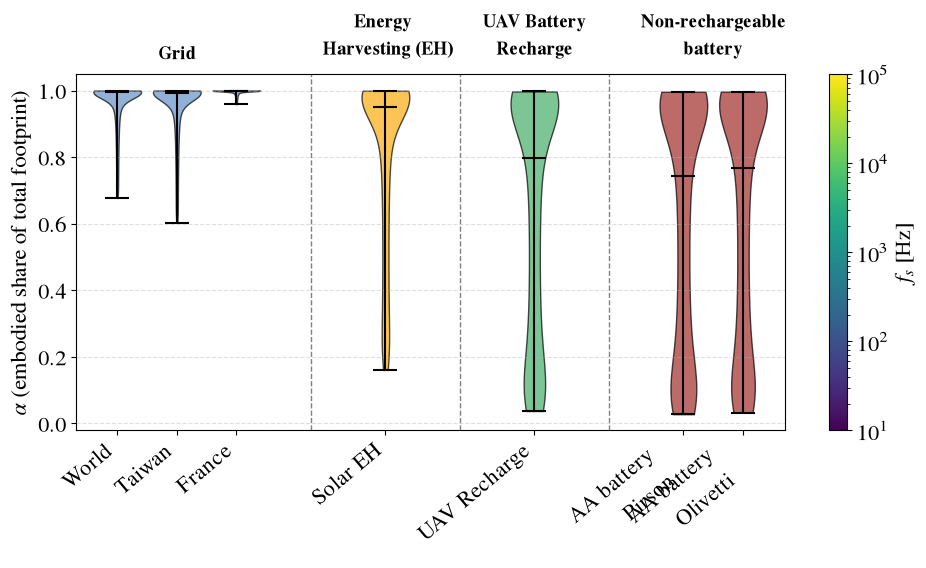

In [446]:

from matplotlib.path import Path
from matplotlib.patches import PathPatch
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

scheme_colors = [dictColor["UnitedBlue"], dictColor["Orange"], dictColor["Green"],dictColor["DeepRed"], dictColor["LightRed"]]

fig, ax = plt.subplots(figsize=(max(10, 0.7 * len(x_labels)), 6))


Nx,Ny=1,1000
imgArr = np.tile(np.linspace(0,1,Ny), (Nx,1)).T
cmap = 'viridis'

norm = matplotlib.colors.LogNorm(vmin=fs_array.min(), vmax=fs_array.max())

for alphas, (start, end), color in zip(scheme_alphas, group_ranges, scheme_colors):
    x_pos = np.arange(start, end + 1)
    #log_alpha = np.log10(alphas)
    dataset = [alphas[i, :] for i in range(alphas.shape[0])]
    parts = ax.violinplot(dataset, positions=x_pos, widths=0.8,
                           showmedians=True, showextrema=True)
    
    for body in parts['bodies']:
        body.set_facecolor(color)
        body.set_edgecolor('black')
        body.set_alpha(0.7)
    for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        parts[key].set_color('black')

    ymin, ymax = ax.get_ylim()
    xmin, xmax = ax.get_xlim()    

    #for violin in parts['bodies']:
    #    path = Path(violin.get_paths()[0].vertices)
    #    patch = PathPatch(path, facecolor='none', edgecolor='none')
    #    ax.add_patch(patch)
    #    img = ax.imshow(imgArr, origin="lower", extent=[xmin,xmax,0,1], aspect="auto",
    #                    cmap=cmap,
    #                    clip_path=patch)

        
for (_, prev_end), (next_start, _) in zip(group_ranges[:-1], group_ranges[1:]):
    ax.axvline((prev_end + next_start) / 2, color='gray', linestyle='--', linewidth=1, zorder=1)

for name, (start, end) in zip(scheme_names, group_ranges):
    ax.text((start + end) / 2, 1.03, name, transform=ax.get_xaxis_transform(),
            ha='center', va='bottom', fontsize=13, fontweight='bold')
    
#for alphas, (start, end) in zip(scheme_alphas, group_ranges):
#    x_pos = np.arange(start, end + 1)
#    for i, pos in enumerate(x_pos):
#        ax.scatter(pos*np.ones((len(fs_array[::10]))), alphas[i, ::10], color = 'black', s=30,
#                   edgecolor='black', linewidth=0, zorder=3)

sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'$f_s$ [Hz]')

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=40, ha='right')
ax.set_xlim(-0.7, offset - gap - 0.3)

ax.set_ylabel(r'$\alpha$ (embodied share of total footprint)')
#ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, _: r'$10^{%d}$' % round(y)))
ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.4)

handles = [mpatches.Patch(facecolor=c, edgecolor='black', alpha=0.7, label=n)
           for c, n in zip(scheme_colors, scheme_names)]
#ax.legend(handles=handles, loc='upper left')

fig.tight_layout()
plt.show()

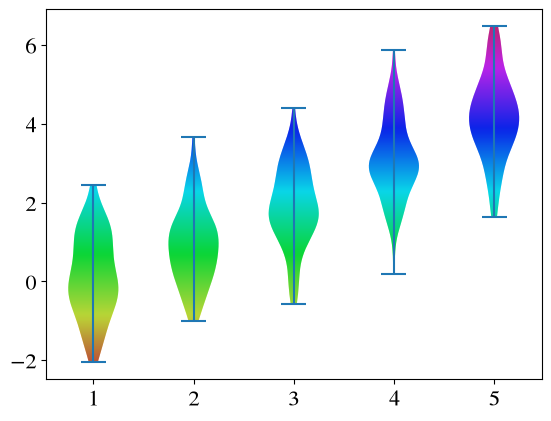

In [43]:


from matplotlib.path import Path
from matplotlib.patches import PathPatch
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable


x = [np.random.normal(loc=i, scale=1, size=(100,)) for i in range(5)]

fig, ax = plt.subplots()
violins = ax.violinplot(x)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

# create a numpy image to use as a gradient
Nx,Ny=1,1000
imgArr = np.tile(np.linspace(0,1,Ny), (Nx,1)).T
cmap = 'hsv'

for violin in violins['bodies']:
    path = Path(violin.get_paths()[0].vertices)
    patch = PathPatch(path, facecolor='none', edgecolor='none')
    ax.add_patch(patch)
    img = ax.imshow(imgArr, origin="lower", extent=[xmin,xmax,ymin,ymax], aspect="auto",
                    cmap=cmap,
                    clip_path=patch)

# colorbar
